In [1]:
!pip install praw pandas matplotlib 

In [2]:
import pandas as pd
import sys
import json
import string
from collections import Counter
import nltk
import re
import html
#for messy text in comments, helps removes non-lexicon data for cleaner analysis
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer()

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

nltk.download('stopwords')
import matplotlib.pyplot as mpl



[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/forsc1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
#Function to pre-process reddit data

def processText(text, tokenizer, stemmer, stopwords):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    
    lTokens = tokenizer.tokenize(text)
    lTokens = [token.strip() for token in lTokens]

    #removing stop words before stemming
    lTokens = [tok for tok in lTokens if tok not in stopwords and not tok.isdigit()]

    lStemmedTokens = [stemmer.stem(tok) for tok in lTokens]
    
    return lStemmedTokens

    

In [4]:
#doing tokenization stopword removal and stemming to furher clean the data

fJsonName = "rawComments.json"
dfComments = pd.read_json("rawComments.json")

#removing deleted and duplicated comments
dfComments = dfComments.dropna(subset=["body"])
dfComments = dfComments[~dfComments["body"].isin(["[deleted]", "[removed]"])]

wordFrequency = 50

lPunct = list(string.punctuation)
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + ['via', 'http', 'https', 'www',]

wordFreqCounter = Counter()

cleanComments = []

for comment in dfComments["body"]:

    lTokens = processText(
        text=str(comment),
        stopwords=lStopwords,
        tokenizer=tokenizer,
        stemmer=stemmer,
    )

    wordFreqCounter.update(lTokens)

    cleanComment = " ".join(lTokens)
    cleanComments.append(cleanComment)

#adding cleaned column
dfComments["cleanBody"] = cleanComments

#saving cleaned data
dfComments.to_json("cleanComments.json", orient="records")

#printing the most common words to check pre-processing worked
for word, count in wordFreqCounter.most_common(wordFrequency):
    print(word + ': ' + str(count)) 


sanction: 2012
us: 1890
polici: 1381
foreign: 1332
russia: 1174
would: 1090
peopl: 1003
countri: 1000
like: 877
war: 876
govern: 723
think: 683
one: 659
want: 639
go: 622
state: 615
even: 583
get: 578
iran: 578
world: 549
make: 525
russian: 524
israel: 513
say: 513
time: 493
american: 491
right: 479
support: 474
power: 470
oil: 466
ukrain: 465
also: 461
nation: 445
...: 430
thing: 414
much: 393
know: 390
year: 389
use: 382
see: 376
militari: 376
could: 364
polit: 360
way: 358
iraq: 356
need: 354
realli: 351
point: 349
econom: 347
obama: 325


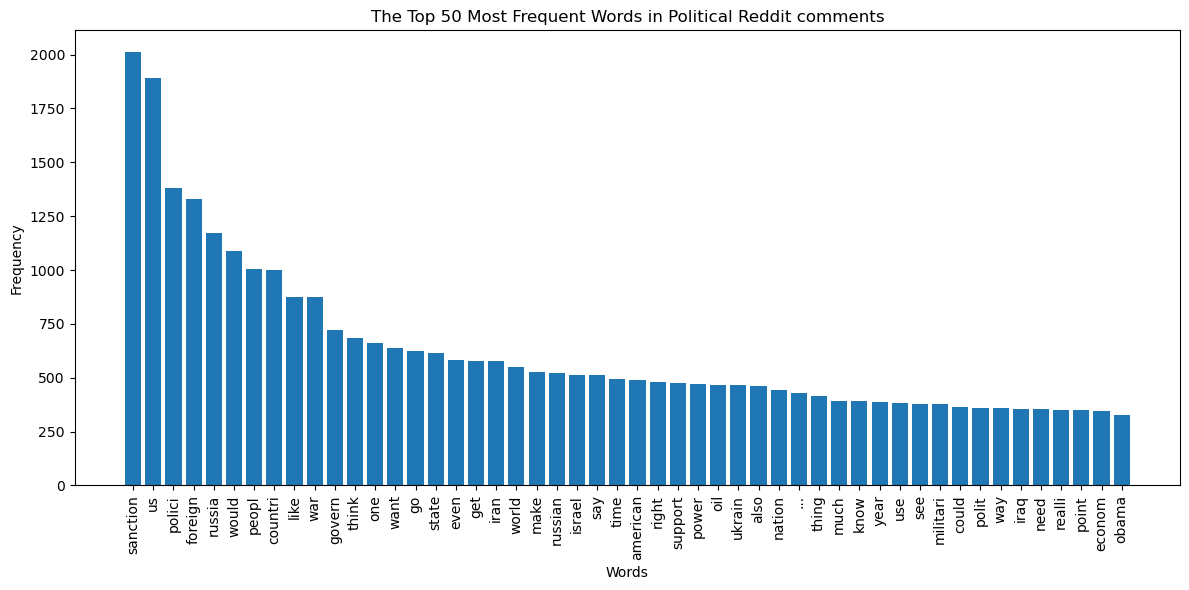

In [5]:
#Data graph for more frequent terms 
words = []
counts = []

for word, count in wordFreqCounter.most_common(wordFrequency):
    words.append(word)
    counts.append(count)

mpl.figure(figsize=(12, 6))
mpl.bar(words, counts)
mpl.xticks(rotation=90)
mpl.title("The Top 50 Most Frequent Words in Political Reddit comments")
mpl.xlabel("Words")
mpl.ylabel("Frequency")
mpl.tight_layout()
mpl.show()
